In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider
from scipy.optimize import curve_fit
import scipy.interpolate as interp
import camb
from camb import model, initialpower

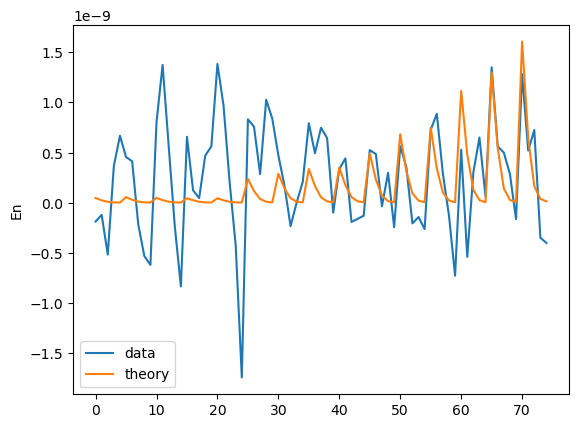

In [2]:
theory = np.loadtxt("data-theory(kids_nl_theta60).txt", skiprows=1)[:,1]
data = np.loadtxt("data-theory(kids_nl_theta60).txt", skiprows=1)[:,0]

plt.plot(data, label = "data")
plt.plot(theory, label = "theory")
plt.ylabel("En")
plt.legend();

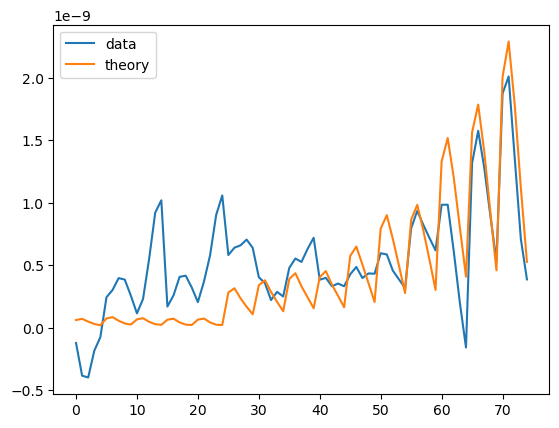

In [4]:
theory = np.loadtxt("data-theory(kids_nl).txt", skiprows=1)[:,1]
data = np.loadtxt("data-theory(kids_nl).txt", skiprows=1)[:,0]

plt.plot(data, label = "data")
plt.plot(theory, label = "theory")
plt.legend();

/tmp/ipykernel_154204/1120535280.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend();


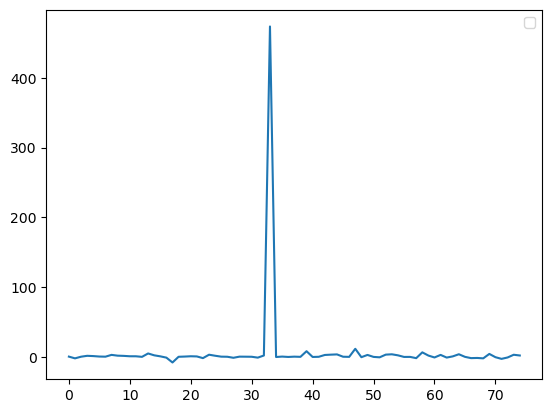

In [4]:
x=0 #0:theory , 1:data , 2:diff , 3:diff_frac(/data), 4:diff_frac(/theory)
datatheory = np.loadtxt("data-theory(kids_nl_theta60).txt", skiprows=1)[:,x]
datatheorykidsnl = np.loadtxt("data-theory(kids_nl).txt", skiprows=1)[:,x]
cov = np.loadtxt("cov_theta60.txt")
covkidsnl = np.loadtxt("cov_kids_nl.txt")

diff= [(datatheory -datatheorykidsnl),(datatheory - datatheorykidsnl)/datatheory]

# plt.plot(datatheorykidsnl, label = "0.5")
# plt.plot(datatheory, label = "60.0")
plt.plot(diff[1])
plt.legend();
# plt.plot(diff015)
# print(np.where(np.abs(datatheory)>200))
# print(datatheory.shape)


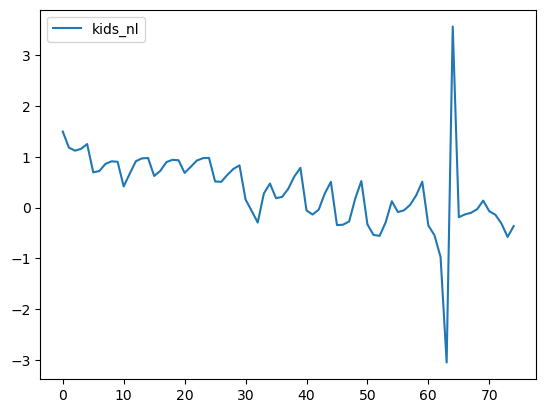

In [5]:
x=3 #0:theory , 1:data , 2:diff , 3:diff_frac
datatheoryme = np.loadtxt("data-theory(me_lin).txt", skiprows=1)[:,x]
datatheorykids = np.loadtxt("data-theory(kids_lin).txt", skiprows=1)[:,x]
datatheorykidsnl = np.loadtxt("data-theory(kids_nl).txt", skiprows=1)[:,x]
diff= (datatheoryme -datatheorykids)/datatheoryme
# plt.plot(datatheoryme, markersize = 4,label = "me")
# plt.plot(datatheorykids, label = "kids_lin")
plt.plot(datatheorykidsnl, label = "kids_nl")
plt.legend();
# plt.plot(diff)

x=3 #0:theory , 1:data , 2:diff , 3:diff_frac
datatheoryme015 = np.loadtxt("data-theory(me_lin015).txt", skiprows=1)[:,x]
datatheorykids015 = np.loadtxt("data-theory(kids_lin015).txt", skiprows=1)[:,x]
# datatheorykidsnl015 = np.loadtxt("data-theory(kids_nl015).txt", skiprows=1)[:,x]
diff015= (datatheoryme015 -datatheorykids015)/datatheoryme015
# plt.plot(datatheoryme015, markersize = 4,label = "me")
# plt.plot(datatheorykids, label = "kids_lin")
# plt.plot(datatheorykidsnl, label = "kids_nl")
# plt.legend();
# plt.plot(diff015)


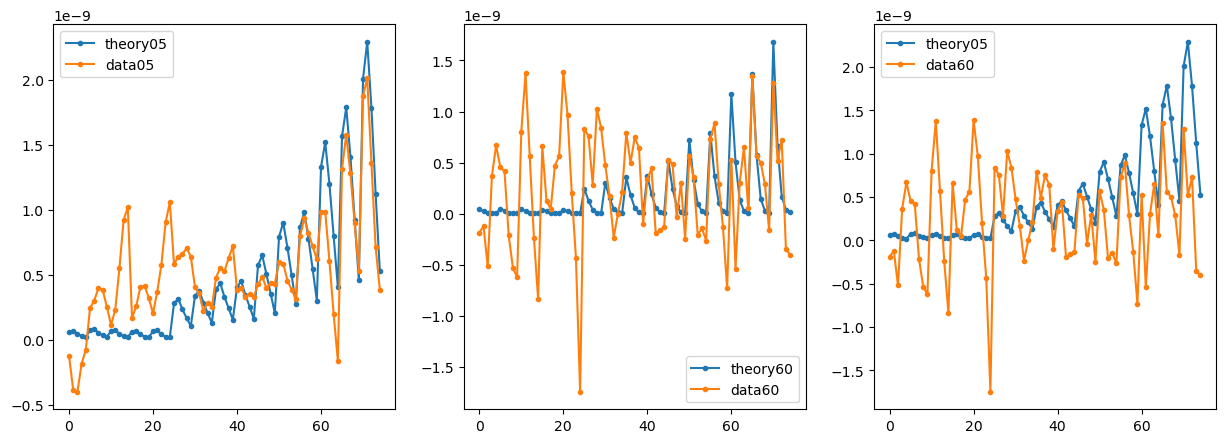

In [4]:
x=0 #0:data , 1:theory , 2:diff , 3:diff_frac(/data), 4:diff_frac(/theory)
dt05 = np.loadtxt("data-theory_theta05.txt", skiprows=1)
dt60 = np.loadtxt("data-theory_data60_theory60.txt", skiprows=1)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.plot(dt05[:,1], label="theory05",marker='.')
plt.plot(dt05[:,0], label="data05",marker='.')
plt.legend();

plt.subplot(1,3,2)
plt.plot(dt60[:,1], label="theory60",marker='.')
plt.plot(dt60[:,0], label="data60",marker='.')
plt.legend();

plt.subplot(1,3,3)
plt.plot(dt05[:,1], label="theory05",marker='.')
plt.plot(dt60[:,0], label="data60",marker='.')
plt.legend();

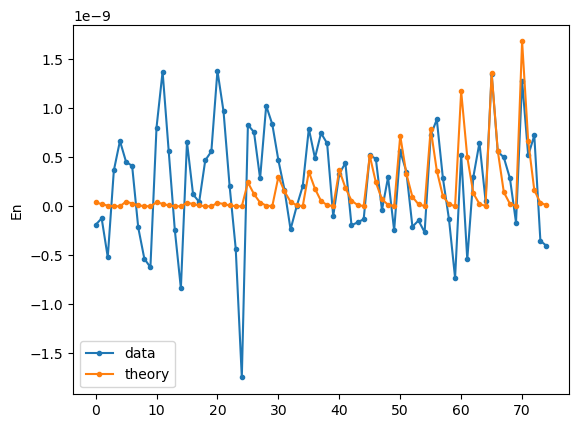

In [25]:
theory = np.loadtxt("data-theory_data60_theory60.txt", skiprows=1)[:,1]
data = np.loadtxt("data-theory_data60_theory60.txt", skiprows=1)[:,0]

plt.plot(data, label = "data",marker = '.')
plt.plot(theory, label = "theory",marker='.')
plt.ylabel("En")
plt.legend();

error05 =  2.071763409028515e-08
error60 =  3.006150671132652e-08


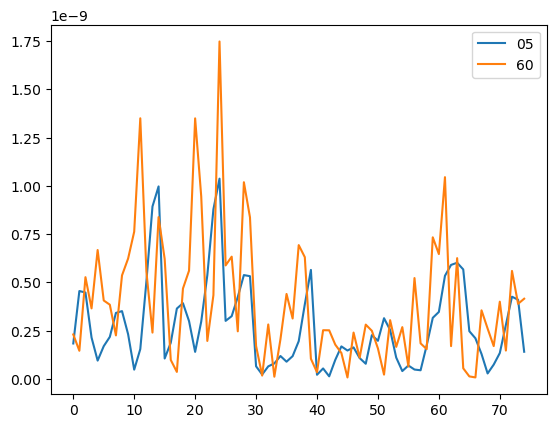

In [16]:
err05 = np.abs(dt05[:,0]-dt05[:,1])
err60 = np.abs(dt60[:,0]-dt60[:,1])

print("error05 = ", np.sum(err05))
print("error60 = ", np.sum(err60))

plt.plot(err05,label="05")
plt.plot(err60,label="60")
plt.legend()

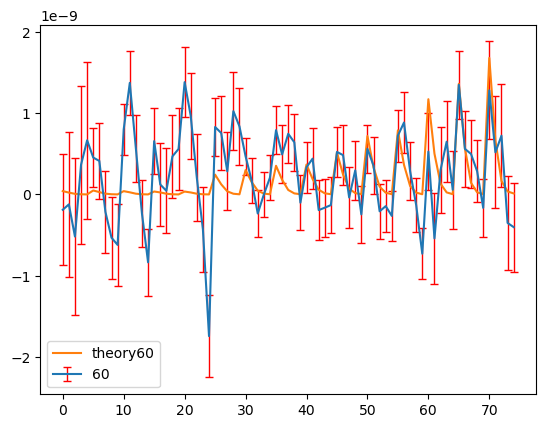

In [69]:
testing = np.loadtxt("data-theory_data05_theory05.txt",skiprows=1)
test_data05 = testing[:,0]
test_theory05 = testing[:,1]
cov05 = np.loadtxt("cov05.txt")
cov60 = np.loadtxt("cov60.txt")
error05 = np.sqrt(np.diag(cov05))
error60 = np.sqrt(np.diag(cov60))

# plt.errorbar(np.arange(len(dt05[:,0])),dt05[:,0],yerr=error05, label="05", capsize=3, ecolor='red',elinewidth=1)
# plt.plot(dt05[:,1], label="theory05")
# plt.legend()
# plt.show()
plt.errorbar(np.arange(len(dt60[:,0])),dt60[:,0],yerr=error60, label="60", capsize=3, ecolor='red',elinewidth=1)
plt.plot(dt60[:,1], label="theory60")
plt.legend()

<ErrorbarContainer object of 3 artists>

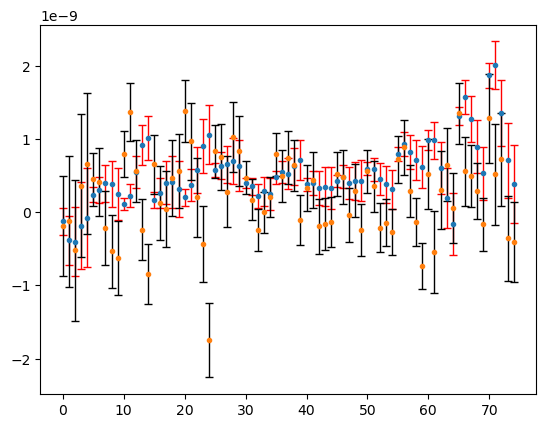

In [75]:
plt.errorbar(np.arange(len(dt05[:,0])),dt05[:,0],yerr=error05, label="05", capsize=3, ecolor='red',elinewidth=1,fmt='.')
# plt.plot(dt60[:,1], label="theory60")
plt.errorbar(np.arange(len(dt60[:,0])),dt60[:,0],yerr=error60, label="60", capsize=3, ecolor='black',elinewidth=1,fmt='.')
# plt.plot(dt60[:,1], label="theory60")

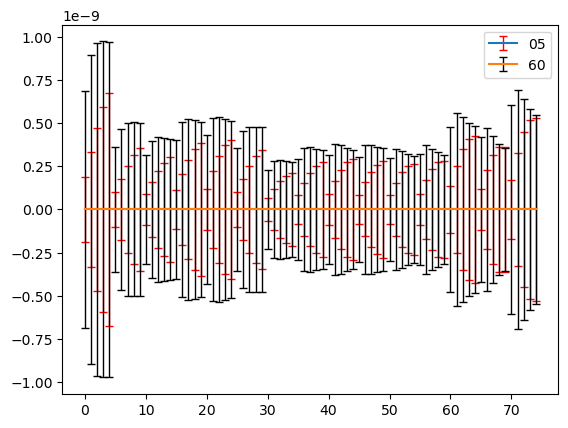

In [80]:
plt.errorbar(np.arange(len(dt05[:,0])),np.zeros_like(dt05[:,0]),yerr=error05, label="05", capsize=3, ecolor='red',elinewidth=1)
plt.errorbar(np.arange(len(dt60[:,0])),np.zeros_like(dt60[:,0]),yerr=error60, label="60", capsize=3, ecolor='black',elinewidth=1)
plt.legend()

/home/steven/env/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/home/steven/env/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


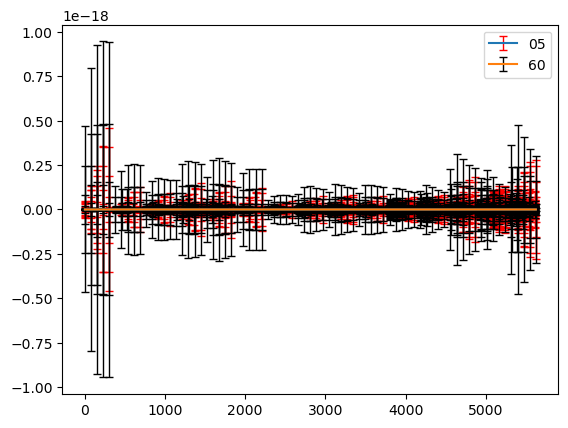

In [101]:
plt.errorbar(np.arange(len(cov05.flatten())),np.zeros_like(cov05.flatten()),yerr=cov05.flatten(), label="05", capsize=3, ecolor='red',elinewidth=1)
plt.errorbar(np.arange(len(cov60.flatten())),np.zeros_like(cov60.flatten()),yerr=np.abs(cov60.flatten()), label="60", capsize=3, ecolor='black',elinewidth=1)
plt.legend()

difference from best like :  9.901585067882527e-09
difference from lcdm 60 :  9.564538007841404e-09


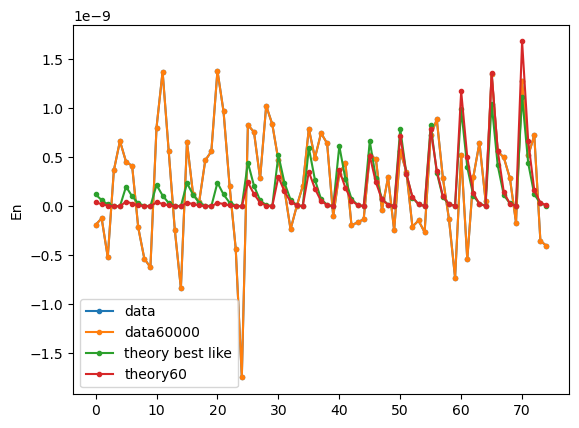

In [34]:
theory_best_like = np.loadtxt("data-theory_best_like_from_chain.txt", skiprows=1)[:,1]
data = np.loadtxt("data-theory_best_like_from_chain.txt", skiprows=1)[:,0]

diff_best_like = np.abs(theory_best_like-data)
diff_lcdm_60 = np.abs(dt60[:,1]-data)
# diff_lcdm_05 = np.abs(dt05[:,1]-data)
n=40
print("difference from best like : ", np.sum(diff_best_like[n:]))
print("difference from lcdm 60 : ", np.sum(diff_lcdm_60[n:]))
# print("difference from lcdm 05 : ", np.sum(diff_lcdm_05[n:]))

plt.plot(data, label = "data",marker = '.')
plt.plot(dt60[:,0], label = "data60000",marker = '.')
plt.plot(theory_best_like, label = "theory best like",marker='.')
plt.plot(dt60[:,1],label="theory60",marker = '.')
plt.ylabel("En")
plt.legend();

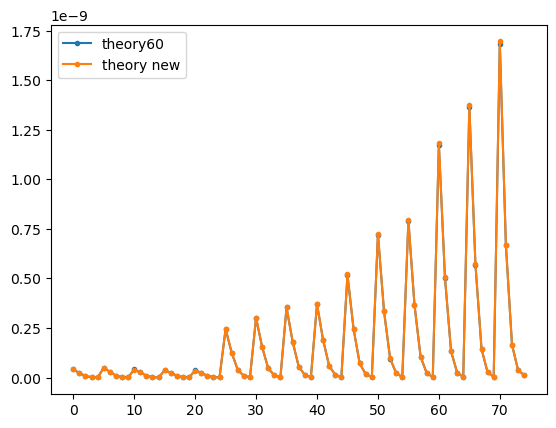

In [2]:
x=0 #0:data , 1:theory , 2:diff , 3:diff_frac(/data), 4:diff_frac(/theory)
dt05 = np.loadtxt("data-theory_theta05.txt", skiprows=1)
dt60 = np.loadtxt("data-theory_data60_theory60.txt", skiprows=1)
dtme = np.loadtxt("data-theory_grad_des.txt",skiprows=1)

plt.plot(dt60[:,1], label="theory60",marker='.')
# plt.plot(dt60[:,0], label="data60",marker='.')
plt.plot(dtme[:,1], label="theory new", marker = '.')
plt.legend();
